# NPS Preditivo - Passo 7: Motor de Inferência e Fila de Risco
Este notebook demonstra de forma interativa e visual como o nosso modelo de produção escoreia novos dados operacionais recebidos, calcula a probabilidade individual de detração, segmenta os clientes em faixas de risco proativas e ordena uma fila priorizada para a tomada de decisões imediatas das áreas de logística e suporte.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Configurações estéticas de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False

## 1. Mapeamento de Caminhos e Carga dos Dados

In [3]:
# Caminho absoluto dinâmico para rodar a partir de qualquer pasta
BASE_DIR = Path(os.getcwd()).resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

INPUT_DATA_PATH = BASE_DIR / "data" / "processed" / "processed_nps_data.csv"
MODEL_PATH = BASE_DIR / "models" / "detractor_classifier.joblib"

df_new = pd.read_csv(INPUT_DATA_PATH)
print(f"✓ Dados operacionais carregados: {df_new.shape[0]} registros.")
df_new.head(3)

✓ Dados operacionais carregados: 2500 registros.


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,is_detractor,delay_group,contacts_group,support_group
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,0,4,6.9,0,3,6.5,0,Atraso Baixo (1-2 dias),Sem Contato,Médio (3-5 dias)
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,0,10,2.4,0,3,0.0,1,Atraso Médio (3-4 dias),Sem Contato,Crítico (9+ dias)
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,4,5,4.8,0,7,1.5,1,Atraso Baixo (1-2 dias),Contato Médio (3-4 contatos),Médio (3-5 dias)


## 2. Carregar o Pipeline Preditivo Serializado

In [4]:
print(f"Carregando pipeline de modelagem serializado de: {MODEL_PATH}")
pipeline = joblib.load(MODEL_PATH)
print("✓ Pipeline preditivo carregado com sucesso!")
print("Estrutura do Pipeline:")
pipeline

Carregando pipeline de modelagem serializado de: /home/userdev/dev/projetos/POSTECH_AI_SCIENTIST/TECH_CHALLENGE_ECOMMERCE/models/detractor_classifier.joblib
✓ Pipeline preditivo carregado com sucesso!
Estrutura do Pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['customer_age','customer_region','customer_tenure_months',..., 'customer_service_contacts','resolution_time_days','complaints_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default

## 3. Inferência: Calcular Probabilidade de Detração
O pipeline pré-processa os novos dados operacionais (imputação e padronização das numéricas + One-Hot Encoding das categóricas) e executa o estimador cego a vazamento de dados.

In [5]:
# Gerar previsões de probabilidade para a classe positiva (1 - Detrator)
probabilities = pipeline.predict_proba(df_new)
detractor_probs = probabilities[:, 1]

# Acoplar a probabilidade calculada ao DataFrame de novos pedidos
df_new["detractor_probability"] = detractor_probs
print("✓ Probabilidades preditas com sucesso!")

✓ Probabilidades preditas com sucesso!


## 4. Classificação das Faixas de Risco (Risk Bands)
De acordo com os limites definidos pelo negócio:
- **Baixo Risco:** Probabilidade <= 50%
- **Alto Risco:** Probabilidade entre 50% e 75%
- **Risco Crítico:** Probabilidade > 75%

In [6]:
def categorize_risk_band(probability):
    if probability <= 0.50:
        return "Baixo Risco"
    elif 0.50 < probability <= 0.75:
        return "Alto Risco"
    else:
        return "Risco Crítico"

df_new["risk_band"] = df_new["detractor_probability"].apply(categorize_risk_band)

risk_counts = df_new["risk_band"].value_counts()
risk_pcts = df_new["risk_band"].value_counts(normalize=True) * 100

print("Distribuição das Faixas de Risco Operacional:")
for band in risk_counts.index:
    print(f"- {band:15s}: {risk_counts[band]:5d} ({risk_pcts[band]:.2f}%)")

Distribuição das Faixas de Risco Operacional:
- Risco Crítico  :  1573 (62.92%)
- Baixo Risco    :   509 (20.36%)
- Alto Risco     :   418 (16.72%)


## 5. Visualização das Faixas de Risco

/tmp/ipykernel_18595/2012141641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


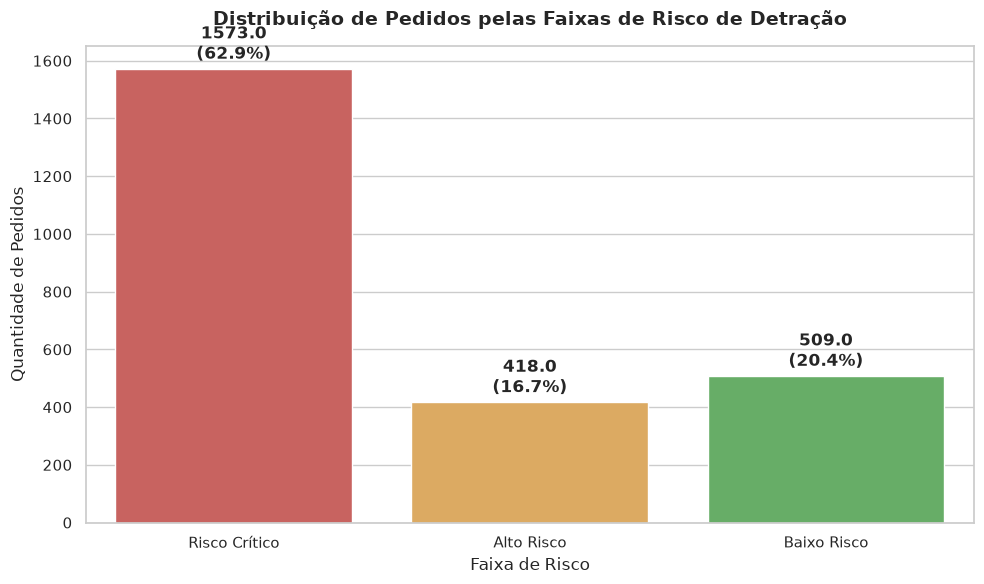

In [7]:
plt.figure(figsize=(10, 6))
colors = {"Risco Crítico": "#d9534f", "Alto Risco": "#f0ad4e", "Baixo Risco": "#5cb85c"}
ax = sns.countplot(
    x="risk_band", 
    data=df_new, 
    palette=colors, 
    order=["Risco Crítico", "Alto Risco", "Baixo Risco"]
)

plt.title("Distribuição de Pedidos pelas Faixas de Risco de Detração", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Faixa de Risco", fontsize=12)
plt.ylabel("Quantidade de Pedidos", fontsize=12)

# Exibir os valores em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}\n({height/len(df_new)*100:.1f}%)',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Priorização e Estruturação da Fila de Risco
Para apoiar a tomada de decisão da operação, a fila deve ser ordenada de modo que os clientes sob **Risco Crítico** com maior probabilidade fiquem no topo da fila, facilitando a ação ativa do suporte/logística.

In [8]:
# Ordenar por prioridade (Risco Crítico primeiro, Alto Risco depois, e maior probabilidade)
risk_order = {"Risco Crítico": 0, "Alto Risco": 1, "Baixo Risco": 2}
df_new["risk_priority"] = df_new["risk_band"].map(risk_order)

df_prioritized = df_new.sort_values(
    by=["risk_priority", "detractor_probability"], 
    ascending=[True, False]
).drop(columns=["risk_priority"])

print("=== TOP 10 CLIENTES DE MAIOR RISCO (FILA DE PRIORIDADE CRÍTICA) ===")
cols_to_show = [
    "customer_id", "customer_region", "delivery_delay_days", 
    "customer_service_contacts", "complaints_count", "detractor_probability", "risk_band"
]
df_prioritized[cols_to_show].head(10)

=== TOP 10 CLIENTES DE MAIOR RISCO (FILA DE PRIORIDADE CRÍTICA) ===


,customer_id,customer_region,delivery_delay_days,customer_service_contacts,complaints_count,detractor_probability,risk_band
1436,1437,Sudeste,7,2,8,0.999929,Risco Crítico
328,329,Centro-Oeste,6,4,9,0.999912,Risco Crítico
2355,2356,Sul,6,5,10,0.999869,Risco Crítico
461,462,Sul,5,6,10,0.999815,Risco Crítico
1422,1423,Centro-Oeste,6,3,8,0.999814,Risco Crítico
1557,1558,Nordeste,5,4,9,0.999806,Risco Crítico
1762,1763,Sul,7,2,6,0.999769,Risco Crítico
595,596,Sul,5,4,9,0.999741,Risco Crítico
766,767,Norte,5,4,8,0.999740,Risco Crítico
1510,1511,Norte,5,2,8,0.999715,Risco Crítico


## 7. Exportar a Base Escorada
Salvando a fila priorizada no arquivo definitivo de produção `scored_orders.csv` para consumo das APIs ou painéis operacionais.

In [9]:
OUTPUT_FILE = BASE_DIR / "data" / "processed" / "scored_orders.csv"
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

df_prioritized.to_csv(OUTPUT_FILE, index=False)
print(f"✓ Processamento Concluído com Sucesso!")
print(f"Fila de risco exportada para: {OUTPUT_FILE.resolve()}")

✓ Processamento Concluído com Sucesso!
Fila de risco exportada para: /home/userdev/dev/projetos/POSTECH_AI_SCIENTIST/TECH_CHALLENGE_ECOMMERCE/data/processed/scored_orders.csv
